ACF computed acf_vals[0:4]: [1.         0.99545169 0.98256092 0.96164013]
Estimated R-R interval : 0.834 s
Estimated heart rate   : 71.9 BPM


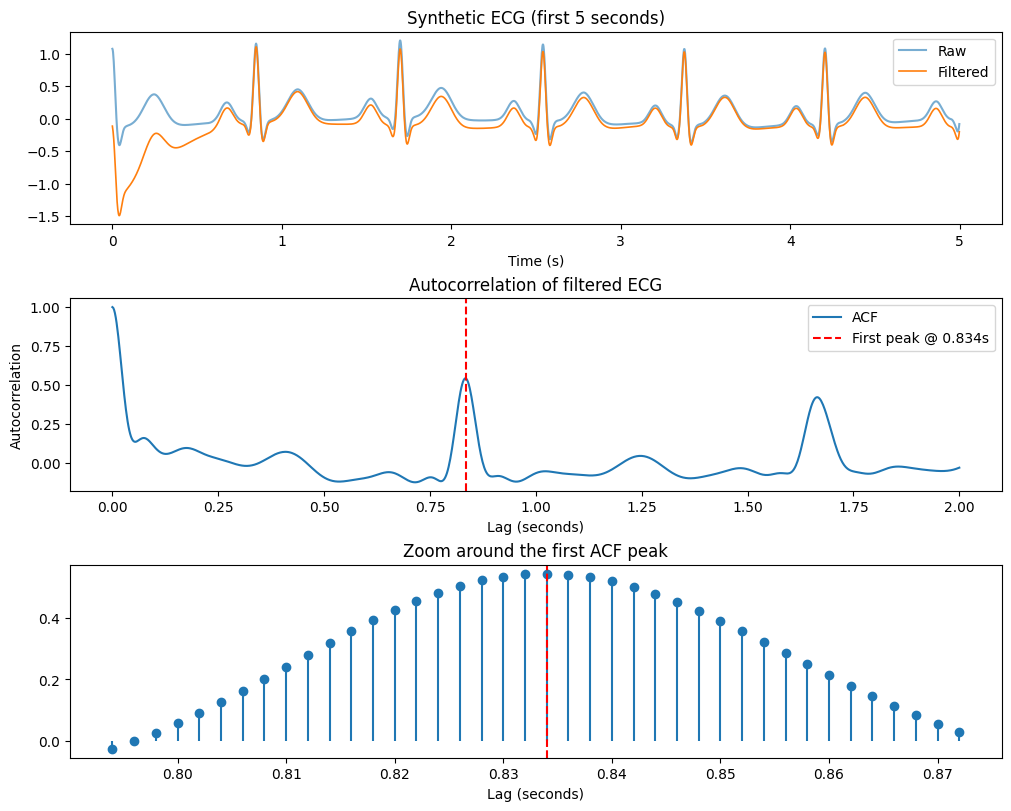

In [ ]:
# =============================================================================
#  ECG‑based heart‑rate estimation using autocorrelation
#  ---------------------------------------------------
#  • Simulated ECG via NeuroKit2
#  • Pre‑processing: band‑pass filter + mean‑centering
#  • Autocorrelation computed with statsmodels.acf
#  • First non‑zero ACF peak → RR interval → BPM
#  • Visualisation for sanity checking
# =============================================================================

# Imports
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk
from scipy.signal import butter, filtfilt, find_peaks
from statsmodels.tsa.stattools import acf

# Helper: simple band‑pass filter (0.5–40 Hz)
def bandpass(signal, fs, low=0.5, high=40, order=2):
    """Butterworth band-pass filter."""
    nyq = fs / 2.0
    b, a = butter(order, [low / nyq, high / nyq], btype="band")
    return filtfilt(b, a, signal)

# Simulate a synthetic ECG
fs          = 500          # sampling frequency (Hz)
duration_s  = 30           # seconds of data
target_hr   = 72           # nominal heart rate (BPM)

# NeuroKit2 returns a 1‑D NumPy array
ecg_raw = nk.ecg_simulate(duration=duration_s,
                           sampling_rate=fs,
                           heart_rate=target_hr,
                           noise=0.01)   # small Gaussian noise


# Pre‑process the signal
ecg_filt = bandpass(ecg_raw, fs)       # remove baseline wander & HF noise
# Subtracts the average value of the filtered signal so 
# that the signal oscillates around zero. This step makes the zero‑lag 
# autocorrelation value reflect pure similarity rather than 
# being inflated by a DC offset.
ecg_filt = ecg_filt - np.mean(ecg_filt)   # mean‑center (helps autocorr.)


# Compute autocorrelation (statsmodels)
max_lag_sec = 2.0                       # look up to 2 s ahead (covers slow HR)
nlags       = int(max_lag_sec * fs)     # number of lag samples

# `acf` returns an array of length nlags+1 (lag = 0 … nlags)
acf_vals = acf(ecg_filt, nlags=nlags, fft=True)

# Find the first *non‑zero* peak
# Parameters for peak detection
relative_height = 0.30                  # require ≥30 % of zero‑lag value
min_distance_samples = int(0.2 * fs)    # physiological minimum spacing (~200 ms)

# Search only after lag = 0
peaks, properties = find_peaks(
    acf_vals[1:],                                 # drop lag = 0
    height=relative_height * acf_vals[0],         # height threshold
    distance=min_distance_samples                 # avoid implausibly close peaks
)

if len(peaks) == 0:
    raise RuntimeError("No suitable autocorrelation peak found - check preprocessing.")

# first_peak_idx is the lag index (i.e., the number of samples) 
# at which the first non‑zero autocorrelation peak occurs.
# `peaks` is indexed relative to the sliced array, so add 1 back to get the true lag index
first_peak_idx = peaks[0] + 1

# Convert lag index → seconds → BPM
# Because the ECG was sampled at a known rate fs (samples per second), 
# each sample corresponds to a time interval of $Δt=1/fs$ seconds.
# from that we can calculate the R-R interval in seconds, and then convert to BPM.
rr_interval_sec = first_peak_idx / fs
heart_rate_bpm  = 60.0 / rr_interval_sec

print(f"Estimated R-R interval : {rr_interval_sec:.3f} s")
print(f"Estimated heart rate   : {heart_rate_bpm:.1f} BPM")

# Plot results (optional but highly recommended)
t = np.arange(len(ecg_raw)) / fs   # time axis in seconds
lags_sec = np.arange(len(acf_vals)) / fs

fig, axs = plt.subplots(3, 1, figsize=(10, 8), constrained_layout=True)

# 7a – Raw vs. filtered ECG (first 5 s)
axs[0].plot(t[:5*fs], ecg_raw[:5*fs], label="Raw", alpha=0.6)
axs[0].plot(t[:5*fs], ecg_filt[:5*fs], label="Filtered", linewidth=1.2)
axs[0].set_title("Synthetic ECG (first 5 seconds)")
axs[0].set_xlabel("Time (s)")
axs[0].legend()

# 7b – Full autocorrelation function
axs[1].plot(lags_sec, acf_vals, label="ACF")
axs[1].axvline(rr_interval_sec, color='r', linestyle='--',
               label=f'First peak @ {rr_interval_sec:.3f}s')
axs[1].set_title("Autocorrelation of filtered ECG")
axs[1].set_xlabel("Lag (seconds)")
axs[1].set_ylabel("Autocorrelation")
axs[1].legend()


# ----------- 7c – Zoom around the first peak  ----------
# Ensure we stay inside the array bounds
zoom_start = max(0, first_peak_idx - 20)
zoom_end   = min(first_peak_idx + 20, len(lags_sec))

# Slice the data – both arrays now have identical length
x_zoom = lags_sec[zoom_start:zoom_end]
y_zoom = acf_vals[zoom_start:zoom_end]

# Stem plot (compatible with all recent Matplotlib versions)
axs[2].stem(
    x_zoom,
    y_zoom,
    linefmt='C0-',      # colour/style of the stems
    markerfmt='C0o',    # colour/style of the markers
    basefmt=' ',        # no baseline line (empty string works everywhere)
)
axs[2].axvline(rr_interval_sec, color='r', linestyle='--')
axs[2].set_title("Zoom around the first ACF peak")
axs[2].set_xlabel("Lag (seconds)")

plt.show()

### Difference between autocorrelation and partial autocorrelation

Autocorrelation looks at how similar the list is to a shifted version of itself.
If you move the whole list a little to the right (say one second) and compare the two columns, you see how much the values line up.
The result is a number between ‑1 and +1.
- +1 means the two columns match perfectly.
- 0 means there is no relationship.
- ‑1 means they are opposite.
You do this for many shifts (1 second, 2 seconds, 3 seconds …).
The series of numbers you obtain is called the autocorrelation function (ACF).
It tells you whether the data repeats itself after a certain amount of time.

When you look at a shift of, for example, 3 seconds, the ordinary autocorrelation also includes the influence of the 1‑second and 2‑second shifts that sit in between.

Partial autocorrelation tries to remove that “in‑between” effect.
It asks: If I already know the relationship at 1 second and 2 seconds, does the value 3 seconds ago still give me any extra information?
The answer is a new number (again between ‑1 and +1).
Doing this for every shift gives the partial autocorrelation function (PACF). It can be used for finetuning or extra derived features. For instance PACF can tell you how many past samples are needed to predict the next R‑peak, which can improve adaptive thresholds.



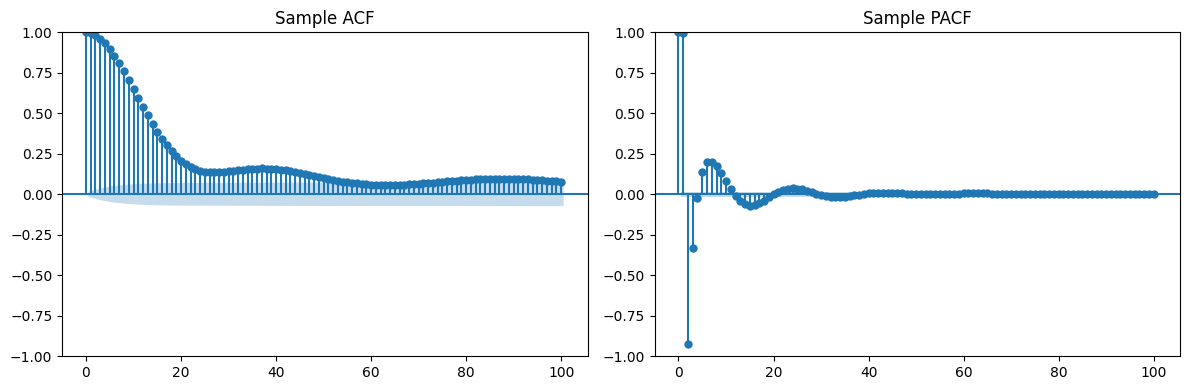

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

max_lag = 100
ts = ecg_filt

acf_vals = acf(ts, nlags=max_lag, fft=True)
pacf_vals = pacf(ts, nlags=max_lag, method='ld')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(ts, lags=max_lag, ax=ax[0], title='Sample ACF')
plot_pacf(ts, lags=max_lag, ax=ax[1], title='Sample PACF')
plt.tight_layout()
plt.show()